## Target (Prediction Task)

**Objective (`y`)**  
Predict whether a **collaboration link** exists between a source artist (`src`) and a destination artist (`dst`) in the collaboration graph.

---

## Link Prediction Motivation

If we can predict **whether two artists will collaborate**, we can then ask:

- What **track-level features** explain or enable that collaboration?
- What **types of collaborations** tend to increase artist popularity?

---

## Prediction Flow

```text
Predict Links
     |
     |-- No  → Why does a collaboration NOT occur?
     |
     |-- Yes
           |
           v
     Predict Track
           |
           v
     Track Popularity
           |
           v
Track Popularity − Avg(Track Popularity)


In [16]:
import numpy as np
import pandas as pd
import plotly.express as px


def plot_corr_slider(
    X,
    feature_names=None,
    method="spearman",
    thresholds=None,
    title="Feature Correlation Matrix (|corr| threshold)",
    text_auto=".2f"
):
    """
    Interactive correlation heatmap with |corr| threshold slider.

    Parameters
    ----------
    X : pd.DataFrame or ndarray (n_samples, n_features)
    feature_names : list[str] or None
    method : {"pearson", "spearman"}
    thresholds : iterable or None
        Values in [0, 1]. Default: np.arange(0, 1.01, 0.1)
    title : str
    text_auto : str or bool
    """

    # -------------------------
    # Prepare data
    # -------------------------
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        df = pd.DataFrame(X, columns=feature_names)

    # Drop constant columns
    df = df.loc[:, df.nunique() > 1]

    corr = df.corr(method=method)

    if thresholds is None:
        thresholds = np.round(np.arange(0.0, 1.01, 0.1), 2)

    # -------------------------
    # Build animation frames
    # -------------------------
    frames = []
    for t in thresholds:
        corr_masked = corr.where(corr.abs() >= t)

        frames.append(
            dict(
                name=str(t),
                data=[dict(
                    type="heatmap",
                    z=corr_masked.values,
                    x=corr.columns,
                    y=corr.index,
                    zmin=-1,
                    zmax=1,
                    colorscale="RdBu"
                )]
            )
        )

    # -------------------------
    # Base figure
    # -------------------------
    fig = px.imshow(
        corr,
        text_auto=text_auto,
        aspect="auto",
        color_continuous_scale="RdBu",
        zmin=-1,
        zmax=1
    )

    fig.update_layout(
        title=title,
        height=max(600, 40 * len(corr)),
        xaxis_tickangle=45,
        sliders=[{
            "steps": [
                {
                    "method": "animate",
                    "label": f"|corr| ≥ {t}",
                    "args": [[str(t)], {"mode": "immediate", "frame": {"duration": 0}}]
                }
                for t in thresholds
            ],
            "currentvalue": {"prefix": "Threshold: "}
        }]
    )

    fig.update(frames=frames)
    fig.show()


In [27]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


def compute_vif(
    X,
    feature_names=None,
    dropna=True,
    scale=True,
    min_rows=10
):
    """
    Compute VIF with NaNs handled inside the calculation.

    Parameters
    ----------
    X : pd.DataFrame or ndarray (n_samples, n_features)
    feature_names : list[str] or None
    dropna : bool
        If True, drop rows with any NaN across selected features
    scale : bool
        If True, standardize features before computing VIF
    min_rows : int
        Minimum number of rows required after NaN dropping

    Returns
    -------
    pd.DataFrame with columns: feature, VIF
    """

    # -------------------------
    # Prepare DataFrame
    # -------------------------
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        df = pd.DataFrame(X, columns=feature_names)

    # Drop constant columns (VIF undefined)
    df = df.loc[:, df.nunique() > 1]

    # -------------------------
    # Drop NaNs *within VIF*
    # -------------------------
    if dropna:
        df = df.dropna(axis=0, how="any")

    if df.shape[0] < min_rows or df.shape[1] < 2:
        return pd.DataFrame({
            "feature": df.columns,
            "VIF": np.nan
        })

    # -------------------------
    # Scale (recommended)
    # -------------------------
    if scale:
        df[:] = StandardScaler().fit_transform(df.values)

    # -------------------------
    # Compute VIF
    # -------------------------
    vif_vals = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]

    vif_df = pd.DataFrame({
        "feature": df.columns,
        "VIF": vif_vals
    }).sort_values("VIF", ascending=False)

    return vif_df


In [1]:
feature_groups = {
    # --------------------------------------------------
    # Global embedding geometry (weak prior)
    # --------------------------------------------------
    "geometry": [
        "cos_sim_src_dst",
        "l2_dist_src_dst",
        "dot_src_dst",
        "abs_diff_mean",
        "abs_diff_max",
    ],

    # --------------------------------------------------
    # Popularity priors (weak but stable)
    # --------------------------------------------------
    "popularity": [
        "popularity_src",
        "popularity_dst",
    ],

    # --------------------------------------------------
    # One-hop reachability proxies (CORE SIGNAL)
    # --------------------------------------------------
    "one_hop": [
        # src → dst
        "max_cos_srcnbr_dst",
        "mean_cos_srcnbr_dst",
        "mean_topk_cos_srcnbr_dst",
        "num_src_neighbors",

        # dst → src
        "max_cos_dstnbr_src",
        "mean_cos_dstnbr_src",
        "mean_topk_cos_dstnbr_src",
        "num_dst_neighbors",
    ],

    # --------------------------------------------------
    # Two-hop graph structure (VERY STRONG SIGNAL)
    # --------------------------------------------------
    "two_hop": [
        "shared_neighbors",
        "jaccard_neighbors",
        "adamic_adar",
        "preferential_attachment",
    ],
}


In [2]:
import pandas as pd
import numpy as np
import sklearn

ARTIST_EMBEDDINGS_X = '/tmp/artist_embeddings_collab_neg.csv'
# Read in the Tracks Features
TRACK_FEATURES_X = "../../../acousticbrainz/data/recording_ml_features.parquet"


In [3]:
artist_embeddings = pd.read_csv(ARTIST_EMBEDDINGS_X)
track_features = pd.read_parquet(TRACK_FEATURES_X)

In [4]:
artist_embeddings.head(2)

,Unnamed: 0,cos_sim_src_dst,l2_dist_src_dst,dot_src_dst,abs_diff_mean,abs_diff_max,popularity_src,popularity_dst,max_cos_srcnbr_dst,mean_cos_srcnbr_dst,...,mean_cos_dstnbr_src,mean_topk_cos_dstnbr_src,num_dst_neighbors,shared_neighbors,jaccard_neighbors,adamic_adar,preferential_attachment,src,dst,label
0,0,0.350474,1.139760,0.350474,0.169282,0.418905,2.7183,4.8553,1.0,1.0,...,0.000000,0.000000,0,0,0.0,0.0,3,90f04a92-606d-4c36-8cb1-3af7d861ee33,617884f3-e53c-4ec7-bd83-7231ad5d7788,1
1,1,0.572784,0.924355,0.572784,0.136770,0.479460,5.0847,4.7349,1.0,1.0,...,0.836858,0.836858,2,0,0.0,0.0,9,cf8782b5-d21d-4b65-bcd5-1387a11e87ea,f5780f10-00e7-4a0d-8ad0-64dc4f421894,1


In [5]:
# src | dst | emb... | popularity | label

y = artist_embeddings['label'].values

In [ ]:
import itertools
all_features = list(itertools.chain(*feature_groups.values()))


In [7]:
X_geom = artist_embeddings[feature_groups['geometry']].values
X_pop = artist_embeddings[feature_groups['popularity']].values
X_one_hop = artist_embeddings[feature_groups['one_hop']].values
X_two_hop = artist_embeddings[feature_groups['two_hop']].values
X = artist_embeddings[all_features].values

In [8]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from scipy import stats


def logistic_elastic_net_diagnostics(
    X,
    y,
    feature_names,
    n_bootstrap=100,
    random_state=42
):
    rng = np.random.RandomState(random_state)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegressionCV(
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.3, 0.5, 0.7, 0.9, 1.0],
            Cs=np.logspace(-4, 2, 20),
            cv=5,
            max_iter=10000,
            n_jobs=-1,
            scoring="neg_log_loss"
        ))
    ])

    # ---- Fit on full data ----
    pipe.fit(X, y)
    base_coef = pipe.named_steps["logit"].coef_.ravel()

    # ---- Bootstrap ----
    boot_coefs = np.zeros((n_bootstrap, X.shape[1]))

    for i in range(n_bootstrap):
        Xb, yb = resample(X, y, random_state=rng.randint(1e9))
        pipe.fit(Xb, yb)
        boot_coefs[i] = pipe.named_steps["logit"].coef_.ravel()

    # ---- Stability metrics ----
    selection_freq = (boot_coefs != 0).mean(axis=0)
    coef_mean = boot_coefs.mean(axis=0)
    coef_std = boot_coefs.std(axis=0)

    # Sign stability (conditional on being selected)
    sign_stability = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        nz = boot_coefs[:, j] != 0
        if nz.any():
            sign_stability[j] = np.abs(np.sign(boot_coefs[nz, j]).mean())
        else:
            sign_stability[j] = np.nan

    # ---- Post-selection Wald tests (approximate) ----
    pvals = np.full(X.shape[1], np.nan)
    selected_idx = np.where(base_coef != 0)[0]

    if len(selected_idx) > 0:
        X_sel = X[:, selected_idx]
        X_sel = SimpleImputer(strategy="median").fit_transform(X_sel)
        X_sel = StandardScaler().fit_transform(X_sel)

        logit = LogisticRegression(
            penalty="none",
            solver="lbfgs",
            max_iter=5000
        ).fit(X_sel, y)

        coef = logit.coef_.ravel()

        # Fisher Information
        p = logit.predict_proba(X_sel)[:, 1]
        W = np.diag(p * (1 - p))
        XtWX = X_sel.T @ W @ X_sel

        try:
            cov = np.linalg.inv(XtWX)
            se = np.sqrt(np.diag(cov))
            z = coef / se
            pvals_sel = 2 * (1 - stats.norm.cdf(np.abs(z)))
            pvals[selected_idx] = pvals_sel
        except np.linalg.LinAlgError:
            pass  # singular matrix → leave NaNs

    # ---- Assemble results ----
    df = pd.DataFrame({
        "feature": feature_names,
        "coef": base_coef,
        "boot_mean": coef_mean,
        "boot_std": coef_std,
        "selection_freq": selection_freq,
        "sign_stability": sign_stability,
        "p_value_approx": pvals
    })

    return df.sort_values(
        ["selection_freq", "sign_stability"],
        ascending=False
    )


In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from scipy import stats
import time
from tqdm import tqdm


def logistic_elastic_net_diagnostics(
    X,
    y,
    feature_names,
    n_bootstrap=100,
    random_state=42,
    cv=5,
):
    """
    Logistic elastic-net diagnostics with:
    - CV performed ONCE for hyperparameter selection
    - Bootstrap performed with fixed hyperparameters
    - Stability + sign metrics
    - Approximate post-selection Wald tests

    Parameters
    ----------
    X : ndarray (n_samples, n_features)
    y : ndarray (n_samples,)
    feature_names : list[str]
    n_bootstrap : int
    random_state : int
    cv : int

    Returns
    -------
    pd.DataFrame
    """

    rng = np.random.RandomState(random_state)
    n_features = X.shape[1]

    # ============================================================
    # 1) Cross-validation (ONCE)
    # ============================================================

    pipe_cv = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegressionCV(
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.5, 0.8, 1.0], # Reducing cuz only 16 features
            Cs=np.logspace(-3, 1, 10),
            cv=cv,
            max_iter=2000,
            n_jobs=1,
            scoring="neg_log_loss"
        ))
    ])
    
    start = time.time()
    pipe_cv.fit(X, y)
    print("Time:", time.time() - start)
    
    logit_cv = pipe_cv.named_steps["logit"]
    base_coef = logit_cv.coef_.ravel()

    best_C = logit_cv.C_[0]
    best_l1 = logit_cv.l1_ratio_[0]

    # ============================================================
    # 2) Bootstrap with FIXED hyperparameters
    # ============================================================

    fast_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=best_C,
            l1_ratio=best_l1,
            max_iter=1500
        ))
    ])

    boot_coefs = np.zeros((n_bootstrap, n_features))

    for i in tqdm(range(n_bootstrap)):
        Xb, yb = resample(X, y, random_state=rng.randint(1e9))
        fast_pipe.fit(Xb, yb)
        boot_coefs[i] = fast_pipe.named_steps["logit"].coef_.ravel()

    # ============================================================
    # 3) Stability metrics
    # ============================================================

    selection_freq = (boot_coefs != 0).mean(axis=0)
    coef_mean = boot_coefs.mean(axis=0)
    coef_std = boot_coefs.std(axis=0)

    sign_stability = np.full(n_features, np.nan)
    for j in range(n_features):
        nz = boot_coefs[:, j] != 0
        if nz.any():
            sign_stability[j] = np.abs(np.sign(boot_coefs[nz, j]).mean())

    # ============================================================
    # 4) Post-selection Wald tests (approximate)
    # ============================================================

    pvals = np.full(n_features, np.nan)
    selected_idx = np.where(base_coef != 0)[0]

    if len(selected_idx) > 0:
        X_sel = X[:, selected_idx]
        X_sel = SimpleImputer(strategy="median").fit_transform(X_sel)
        X_sel = StandardScaler().fit_transform(X_sel)

        logit = LogisticRegression(
            penalty=None,
            solver="lbfgs",
            max_iter=5000
        ).fit(X_sel, y)

        coef = logit.coef_.ravel()
        p = logit.predict_proba(X_sel)[:, 1]
        w = p * (1 - p)

        XtWX = X_sel.T @ (X_sel * w[:, None])

        try:
            cov = np.linalg.inv(XtWX)
            se = np.sqrt(np.diag(cov))
            z = coef / se
            pvals_sel = 2 * (1 - stats.norm.cdf(np.abs(z)))
            pvals[selected_idx] = pvals_sel
        except np.linalg.LinAlgError:
            pass

    # ============================================================
    # 5) Assemble output
    # ============================================================

    df = pd.DataFrame({
        "feature": feature_names,
        "coef": base_coef,
        "boot_mean": coef_mean,
        "boot_std": coef_std,
        "selection_freq": selection_freq,
        "sign_stability": sign_stability,
        "p_value_approx": pvals
    })

    return df.sort_values(
        ["selection_freq", "sign_stability"],
        ascending=False
    )


In [13]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn"
)

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
    module="sklearn"
)

for gr,feat in feature_groups.items():
    df = logistic_elastic_net_diagnostics(
        X=artist_embeddings[feat].values,
        y=y,
        feature_names=feat,
        n_bootstrap=100
    )
    print(f"========================== {gr} ==========================")
    display(df)

Time: 3.3398187160491943


100%|██████████| 100/100 [00:03<00:00, 25.79it/s]

========================== geometry ==========================


,feature,coef,boot_mean,boot_std,selection_freq,sign_stability,p_value_approx
0,cos_sim_src_dst,-0.099834,-0.100006,0.062292,0.97,0.917526,NaN
2,dot_src_dst,-0.099834,-0.100006,0.062292,0.97,0.917526,NaN
1,l2_dist_src_dst,-0.311539,-0.279644,0.191154,0.93,0.913978,NaN
4,abs_diff_max,-0.040660,-0.053077,0.070222,0.92,0.500000,NaN
3,abs_diff_mean,-0.034050,-0.050084,0.139065,0.74,0.324324,NaN


Time: 0.8021578788757324


...

,feature,coef,boot_mean,boot_std,selection_freq,sign_stability,p_value_approx
0,max_cos_srcnbr_dst,3.314811,3.509709,0.793792,1.00,1.000000,0.000954
4,max_cos_dstnbr_src,3.747800,3.828191,1.047336,1.00,1.000000,0.001013
5,mean_cos_dstnbr_src,-15.814963,-14.556847,2.828498,1.00,1.000000,0.642841
6,mean_topk_cos_dstnbr_src,13.480101,12.128738,2.682705,1.00,1.000000,0.849640
7,num_dst_neighbors,-0.143005,-0.117310,0.149668,1.00,0.620000,0.524627
3,num_src_neighbors,0.073125,0.025574,0.115368,0.98,0.224490,0.609571
1,mean_cos_srcnbr_dst,-2.129659,-3.847263,3.457096,0.91,0.956044,0.023301
2,mean_topk_cos_srcnbr_dst,0.000000,1.557006,3.367366,0.76,0.210526,NaN


Time: 14.132708311080933


100%|██████████| 100/100 [00:16<00:00,  6.18it/s]

========================== two_hop ==========================


,feature,coef,boot_mean,boot_std,selection_freq,sign_stability,p_value_approx
0,shared_neighbors,1.624137,1.523822,0.294810,1.00,1.000000,0.000798
2,adamic_adar,0.232777,0.195913,0.125827,1.00,1.000000,0.026062
3,preferential_attachment,2.768505,2.768352,0.091299,1.00,1.000000,0.000000
1,jaccard_neighbors,0.455614,0.639544,0.496470,0.92,0.956522,0.227052


In [17]:

plot_corr_slider(X,all_features)

In [31]:
TO_USE = { "geometry" :["cos_sim_src_dst","dot_src_dst","l2_dist_src_dst"],
            "popularity" :["popularity_dst","popularity_src"],
            "one_hop": ['num_dst_neighbors',"max_cos_srcnbr_dst",'mean_topk_cos_dstnbr_src'],
            "two_hop": ['preferential_attachment','adamic_adar','jaccard_neighbors']
}

In [32]:
for gr, feat in TO_USE.items():
    print(f"=== {gr} ===")
    vif_df = compute_vif(
        artist_embeddings[feat],
        dropna=True
    )
    display(vif_df)


=== geometry ===


/home/jonnym/.local/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



,feature,VIF
0,cos_sim_src_dst,inf
1,dot_src_dst,inf
2,l2_dist_src_dst,25.751818


=== popularity ===


,feature,VIF
0,popularity_dst,1.153297
1,popularity_src,1.153297


...

/tmp/ipykernel_12451/2717176387.py:60: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.02016072  0.29846896 -0.36084588 ... -1.02016072  0.29846896
 -1.02016072]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



,feature,VIF
2,mean_topk_cos_dstnbr_src,1.542372
0,num_dst_neighbors,1.499415
1,max_cos_srcnbr_dst,1.212228


=== two_hop ===


/tmp/ipykernel_12451/2717176387.py:60: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.8488678  -0.13287393 -0.13287393 ...  0.225123   -0.13287393
 -0.96820011]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



,feature,VIF
1,adamic_adar,1.433348
2,jaccard_neighbors,1.382670
0,preferential_attachment,1.061993


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    log_loss, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
from scipy.stats import chi2


def fit_elasticnet_logit_cv(X_train, y_train, cv=5, random_state=42,
                            l1_ratios=(0.5, 0.8, 1.0), Cs=np.logspace(-3, 1, 10)):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegressionCV(
            penalty="elasticnet",
            solver="saga",
            l1_ratios=list(l1_ratios),
            Cs=Cs,
            cv=cv,
            max_iter=3000,
            n_jobs=1,
            scoring="neg_log_loss",
            random_state=random_state
        ))
    ])
    pipe.fit(X_train, y_train)

    logit_cv = pipe.named_steps["logit"]
    best_C = float(logit_cv.C_[0])
    best_l1 = float(logit_cv.l1_ratio_[0])

    return pipe, best_C, best_l1

In [39]:
def hosmer_lemeshow_test(y_true, y_prob, g=10, eps=1e-12):
    """
    Hosmer–Lemeshow goodness-of-fit test for logistic regression.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
    y_prob : array-like of shape (n_samples,) predicted probabilities for class 1
    g : int, number of groups (typically 10)

    Returns
    -------
    hl_stat : float
    df : int
    p_value : float
    table : pd.DataFrame with per-group observed/expected
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    # Guard against exactly 0/1 probs
    y_prob = np.clip(y_prob, eps, 1 - eps)

    # Group by quantiles of predicted risk
    # Use qcut; if too many ties, drop duplicates
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    df["bin"] = pd.qcut(df["p"], q=g, duplicates="drop")

    grouped = df.groupby("bin", observed=False)
    obs_1 = grouped["y"].sum()
    n = grouped.size()
    exp_1 = grouped["p"].sum()
    obs_0 = n - obs_1
    exp_0 = n - exp_1

    # HL statistic
    hl = ((obs_1 - exp_1) ** 2 / (exp_1 + eps) + (obs_0 - exp_0) ** 2 / (exp_0 + eps)).sum()

    # df = (#groups - 2)
    k = len(n)
    dof = max(k - 2, 1)
    p_value = 1 - chi2.cdf(hl, dof)

    table = pd.DataFrame({
        "n": n,
        "obs_1": obs_1,
        "exp_1": exp_1,
        "obs_0": obs_0,
        "exp_0": exp_0,
        "mean_p": grouped["p"].mean()
    }).reset_index(drop=True)

    return float(hl), int(dof), float(p_value), table


In [40]:
def plot_roc(y_true, y_prob, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [58]:
def evaluate_binary_prob_model(y_true, y_prob, threshold=0.5, hl_groups=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    print(sum(y_pred))

    out = {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    hl_stat, hl_df, hl_p, hl_table = hosmer_lemeshow_test(y_true, y_prob, g=hl_groups)
    out.update({
        "hl_stat": hl_stat,
        "hl_df": hl_df,
        "hl_p_value": hl_p,
    })

    return out, hl_table

In [42]:
def plot_calibration(y_true, y_prob, n_bins=10, title="Calibration (Reliability) Plot"):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")

    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_pr(y_true, y_prob, title="Precision–Recall Curve"):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    plt.figure()
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


In [49]:
# -------------------------
# 4) End-to-end helper for each feature group
# -------------------------
def run_group_eval(feature_groups, X_df, y, X_train_idx, X_test_idx,
                   cv=5, random_state=42, hl_groups=10, do_pr=False,threshold = 0.50):
    """
    Parameters
    ----------
    feature_groups : dict[str, list[str]]
    X_df : pd.DataFrame containing all features
    y : array-like
    X_train_idx / X_test_idx : index arrays (or boolean masks) defining split

    Returns
    -------
    metrics_df : pd.DataFrame
    """
    y = np.asarray(y)

    rows = []
    for gr, feat in feature_groups.items():
        X = X_df[feat].values
        X_train, X_test = X[X_train_idx], X[X_test_idx]
        y_train, y_test = y[X_train_idx], y[X_test_idx]

        pipe, best_C, best_l1 = fit_elasticnet_logit_cv(
            X_train, y_train, cv=cv, random_state=random_state
        )

        y_prob = pipe.predict_proba(X_test)[:, 1]

        metrics, hl_table = evaluate_binary_prob_model(
            y_test, y_prob, threshold=threshold, hl_groups=hl_groups
        )

        # charts
        plot_roc(y_test, y_prob, title=f"ROC — {gr}")
        plot_calibration(y_test, y_prob, n_bins=hl_groups, title=f"Calibration — {gr}")
        if do_pr:
            plot_pr(y_test, y_prob, title=f"PR — {gr}")

        rows.append({
            "group": gr,
            "n_features": len(feat),
            "best_C": best_C,
            "best_l1_ratio": best_l1,
            **metrics
        })

        display(pd.DataFrame(hl_table))  # per-bin observed vs expected

    metrics_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
    return metrics_df

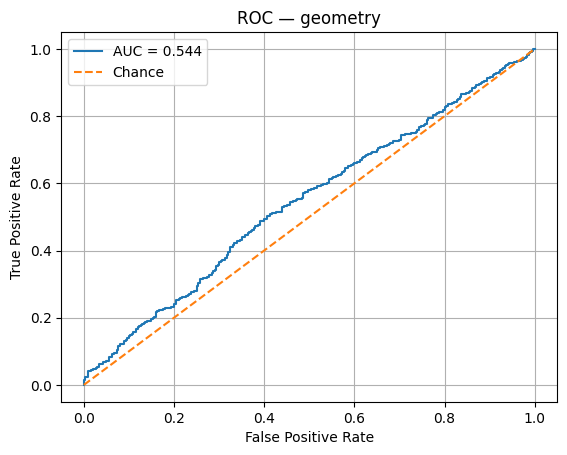

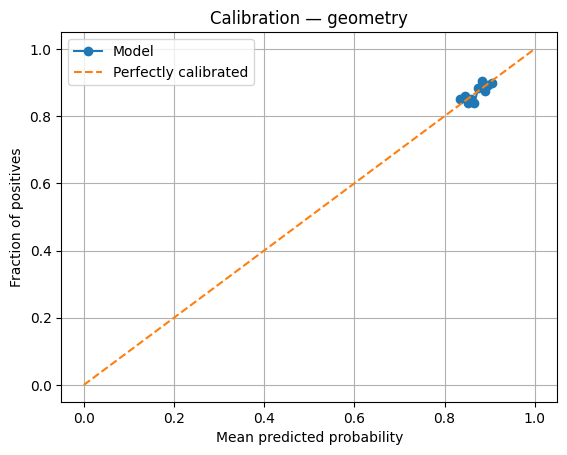

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,230,196,192.075936,34,37.924064,0.835113
1,230,198,194.423234,32,35.576766,0.845318
2,230,193,195.989102,37,34.010898,0.852127
3,230,196,197.464415,34,32.535585,0.858541
4,230,193,199.255924,37,30.744076,0.866330
5,230,203,201.099606,27,28.900394,0.874346
6,230,208,202.877886,22,27.122114,0.882078
7,230,201,204.460718,29,25.539282,0.888960
8,230,205,205.975099,25,24.024901,0.895544
9,230,207,208.393602,23,21.606398,0.906059


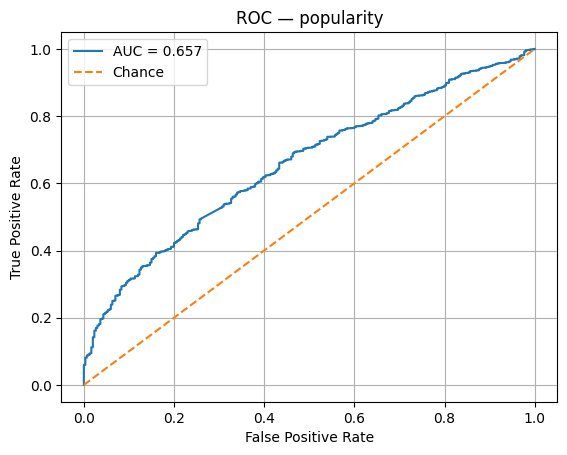

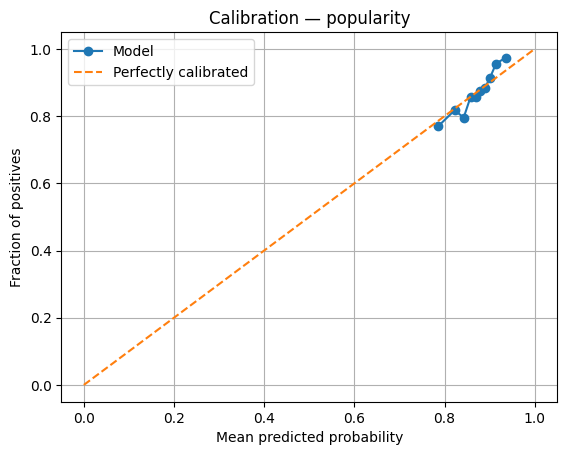

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,230,177,180.700372,53,49.299628,0.785654
1,230,188,189.149879,42,40.850121,0.822391
2,230,183,193.759374,47,36.240626,0.842432
3,230,197,197.242641,33,32.757359,0.857577
4,230,197,200.071181,33,29.928819,0.869875
5,230,201,202.021050,29,27.978950,0.878352
6,230,203,204.426849,27,25.573151,0.888812
7,230,210,207.102931,20,22.897069,0.900448
8,230,220,210.273281,10,19.726719,0.914232
9,230,224,215.214168,6,14.785832,0.935714


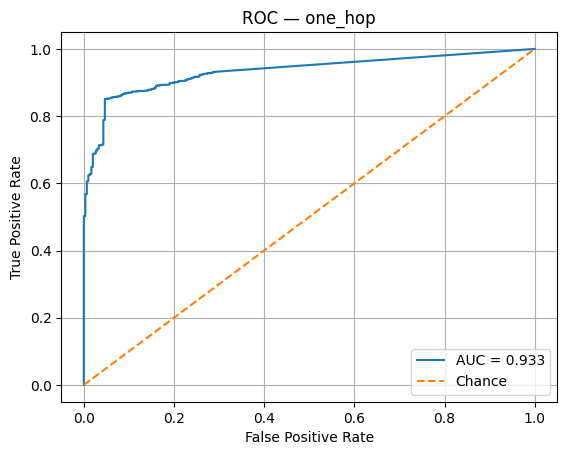

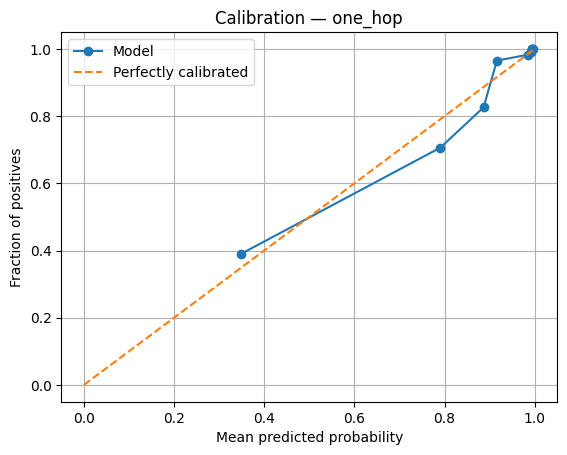

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,460,214,208.717499,246,251.282501,0.453734
1,230,190,203.898393,40,26.101607,0.886515
2,230,222,210.705024,8,19.294976,0.916109
3,230,226,226.336817,4,3.663183,0.984073
4,230,228,227.860471,2,2.139529,0.990698
5,230,230,228.424606,0,1.575394,0.993150
6,230,230,228.511696,0,1.488304,0.993529
7,230,230,228.775564,0,1.224436,0.994676
8,230,230,229.346096,0,0.653904,0.997157


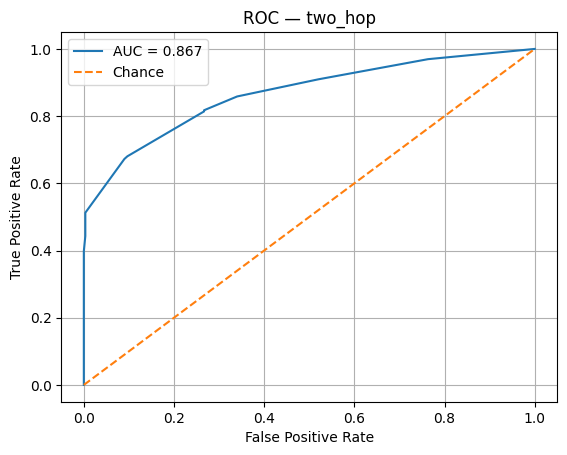

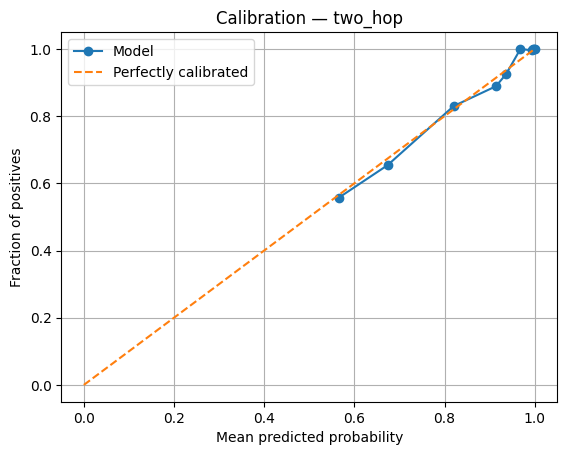

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,325,181,183.644165,144,141.355835,0.565059
1,156,102,105.065150,54,50.934850,0.673495
2,429,356,351.838479,73,77.161521,0.820136
3,18,16,16.450433,2,1.549567,0.913913
4,346,320,324.007082,26,21.992918,0.936437
5,137,137,132.666467,0,4.333533,0.968368
6,231,230,229.464254,1,1.535746,0.993352
7,198,198,197.324191,0,0.675809,0.996587
8,230,230,229.804655,0,0.195345,0.999151
9,230,230,229.992844,0,0.007156,0.999969


,group,n_features,best_C,best_l1_ratio,roc_auc,pr_auc,log_loss,brier,accuracy,precision,recall,f1,hl_stat,hl_df,hl_p_value
2,one_hop,3,0.464159,0.5,0.933268,0.987050,0.214287,0.067862,0.903043,0.955875,0.9315,0.943530,20.821666,7,0.004043
3,two_hop,3,0.464159,0.5,0.866537,0.973504,0.272758,0.087741,0.869565,0.869565,1.0000,0.930233,7.102005,8,0.525668
1,popularity,2,0.464159,0.5,0.657472,0.929350,0.371520,0.110117,0.869565,0.869565,1.0000,0.930233,15.913311,8,0.043638
0,geometry,3,3.593814,0.5,0.544417,0.889500,0.385746,0.113115,0.869565,0.869565,1.0000,0.930233,4.676545,8,0.791522


In [44]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)

metrics_df = run_group_eval(
    feature_groups=TO_USE,
    X_df=artist_embeddings,   # or whatever df contains all feature cols
    y=y,
    X_train_idx=train_idx,
    X_test_idx=test_idx,
    cv=5,
    hl_groups=10,
    do_pr=False
)

display(metrics_df)


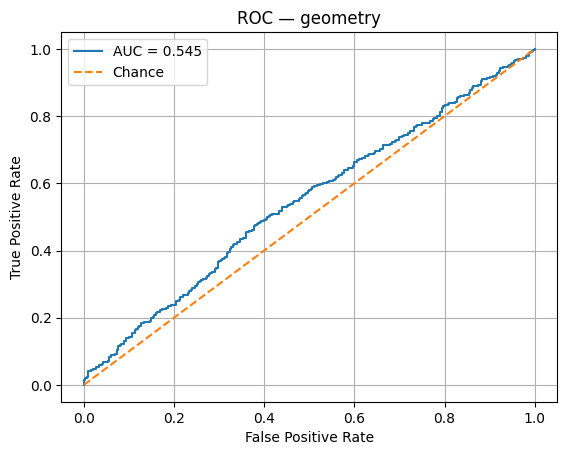

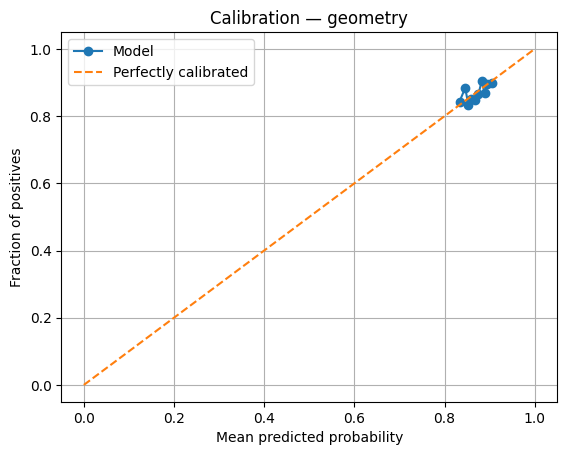

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,230,194,191.662514,36,38.337486,0.833315
1,233,206,197.070044,27,35.929956,0.845794
2,227,189,193.625483,38,33.374517,0.852976
3,230,196,197.743009,34,32.256991,0.859752
4,230,195,199.483180,35,30.516820,0.867318
5,230,199,201.275595,31,28.724405,0.875111
6,230,208,202.948852,22,27.051148,0.882386
7,230,200,204.400043,30,25.599957,0.888696
8,230,206,205.781019,24,24.218981,0.894700
9,230,207,207.970294,23,22.029706,0.904219


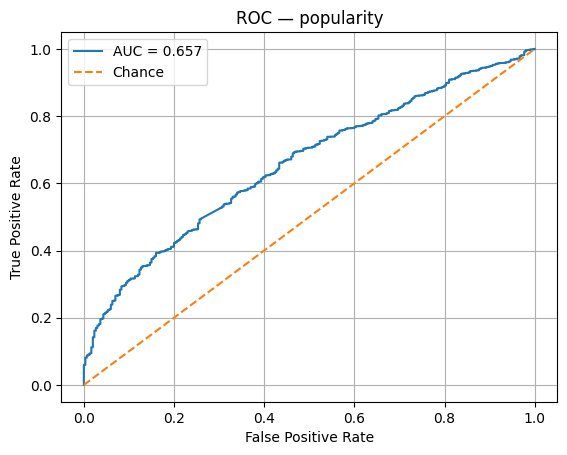

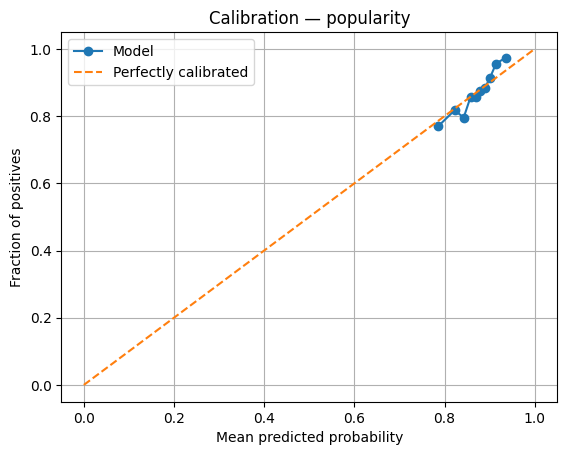

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,230,177,180.700372,53,49.299628,0.785654
1,230,188,189.149879,42,40.850121,0.822391
2,230,183,193.759374,47,36.240626,0.842432
3,230,197,197.242641,33,32.757359,0.857577
4,230,197,200.071181,33,29.928819,0.869875
5,230,201,202.021050,29,27.978950,0.878352
6,230,203,204.426849,27,25.573151,0.888812
7,230,210,207.102931,20,22.897069,0.900448
8,230,220,210.273281,10,19.726719,0.914232
9,230,224,215.214168,6,14.785832,0.935714


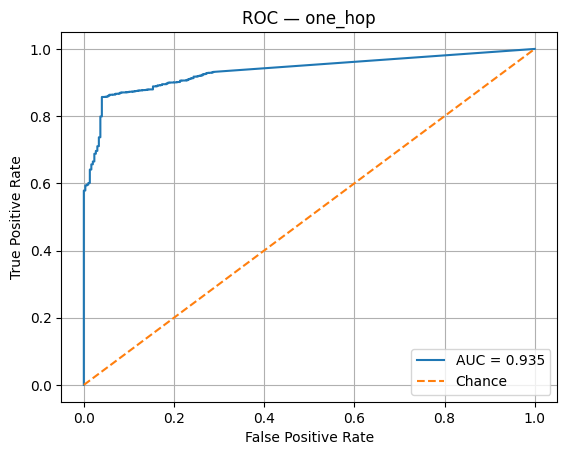

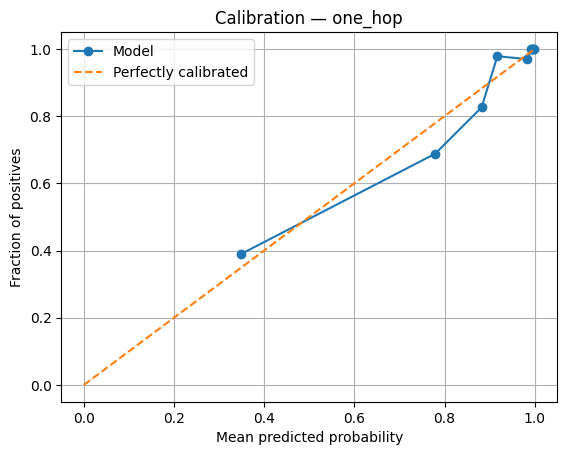

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,460,212,207.638849,248,252.361151,0.451389
1,230,190,202.902786,40,27.097214,0.882186
2,230,225,210.941032,5,19.058968,0.917135
3,230,223,226.262381,7,3.737619,0.983749
4,230,230,227.970733,0,2.029267,0.991177
5,230,230,228.362720,0,1.637280,0.992881
6,230,230,228.597049,0,1.402951,0.993900
7,230,230,229.162227,0,0.837773,0.996358
8,230,230,229.719007,0,0.280993,0.998778


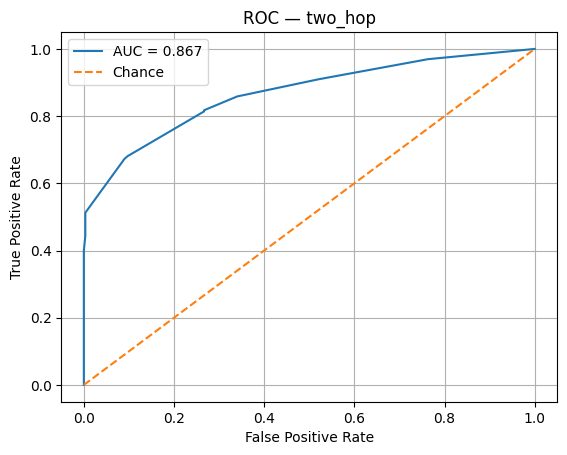

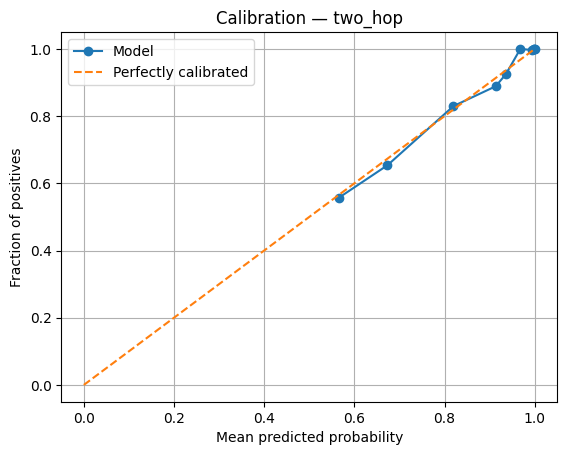

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,325,181,183.742233,144,141.257767,0.565361
1,156,102,105.057497,54,50.942503,0.673445
2,429,356,351.673699,73,77.326301,0.819752
3,18,16,16.442802,2,1.557198,0.913489
4,346,320,323.874750,26,22.125250,0.936054
5,137,137,132.630531,0,4.369469,0.968106
6,302,301,300.314047,1,1.685953,0.994417
7,133,133,132.677531,0,0.322469,0.997575
8,257,257,256.853285,0,0.146715,0.999429
9,197,197,196.997157,0,0.002843,0.999986


,group,n_features,best_C,best_l1_ratio,roc_auc,pr_auc,log_loss,brier,accuracy,precision,recall,f1,hl_stat,hl_df,hl_p_value
2,one_hop,8,10.000000,1.0,0.935105,0.987409,0.212210,0.067484,0.903043,0.955875,0.9315,0.943530,27.563732,7,0.000264
3,two_hop,4,0.464159,0.5,0.866540,0.973506,0.272650,0.087742,0.869565,0.869565,1.0000,0.930233,6.791666,8,0.559268
1,popularity,2,0.464159,0.5,0.657472,0.929350,0.371520,0.110117,0.869565,0.869565,1.0000,0.930233,15.913311,8,0.043638
0,geometry,5,0.464159,0.5,0.544622,0.889496,0.385816,0.113132,0.869565,0.869565,1.0000,0.930233,6.590947,8,0.581338


In [46]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)

metrics_df = run_group_eval(
    feature_groups=feature_groups,
    X_df=artist_embeddings,   # or whatever df contains all feature cols
    y=y,
    X_train_idx=train_idx,
    X_test_idx=test_idx,
    cv=5,
    hl_groups=10,
    do_pr=False
)

display(metrics_df)


In [47]:
import itertools
to_use_comb = list(itertools.chain(*TO_USE.values()))
to_use_dict = {"Full Model" : to_use_comb}

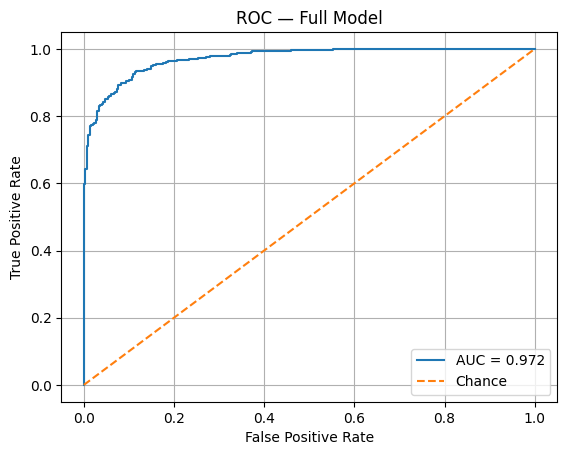

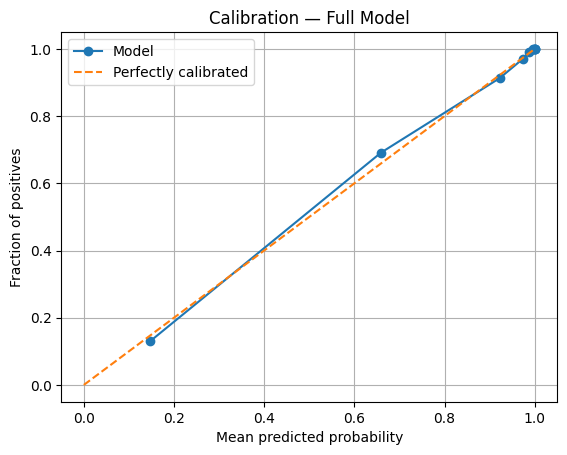

,n,obs_1,exp_1,obs_0,exp_0,mean_p
0,230,30,33.921744,200,196.078256,0.147486
1,230,159,151.591988,71,78.408012,0.659096
2,230,210,212.124009,20,17.875991,0.922278
3,230,223,223.769484,7,6.230516,0.972911
4,230,228,227.314847,2,2.685153,0.988325
5,230,230,229.100678,0,0.899322,0.996090
6,230,230,229.764735,0,0.235265,0.998977
7,230,230,229.941829,0,0.058171,0.999747
8,230,230,229.988901,0,0.011099,0.999952
9,230,230,229.999444,0,0.000556,0.999998


,group,n_features,best_C,best_l1_ratio,roc_auc,pr_auc,log_loss,brier,accuracy,precision,recall,f1,hl_stat,hl_df,hl_p_value
0,Full Model,11,0.464159,0.5,0.97213,0.995601,0.136609,0.040527,0.926957,0.979079,0.936,0.957055,3.350174,8,0.910502


In [50]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)

metrics_df = run_group_eval(
    feature_groups=to_use_dict,
    X_df=artist_embeddings,   # or whatever df contains all feature cols
    y=y,
    X_train_idx=train_idx,
    X_test_idx=test_idx,
    cv=5,
    hl_groups=10,
    do_pr=False,
    threshold = .75,
)

display(metrics_df)


In [52]:
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)

X = artist_embeddings[feat].values
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


pipe, best_C, best_l1 = fit_elasticnet_logit_cv(
    X_train, y_train, cv=5, random_state=67
)

y_prob = pipe.predict_proba(X_test)[:, 1]


In [59]:
rows = []
thresholds = np.arange(0.4, 1, 0.05)
for i in thresholds:
    print("Threshold:",i)
    met, tab = evaluate_binary_prob_model(y_test,y_prob,i)
    rows.append(met)


Threshold: 0.4
2300
Threshold: 0.45
2300
Threshold: 0.5
2300
Threshold: 0.55
2168
Threshold: 0.6
1975
Threshold: 0.6499999999999999
1975
Threshold: 0.7
1819
Threshold: 0.75
1715
Threshold: 0.7999999999999999
1708
Threshold: 0.8499999999999999
1390
Threshold: 0.8999999999999999
1390
Threshold: 0.9499999999999998
1026


In [61]:
df = pd.DataFrame(rows)
df['Thresholds'] = thresholds
# df = df[['Thresholds'] + [c for c in df.columns if c != 'Thresholds']]

df[["Thresholds","accuracy","precision","recall","f1","hl_stat","hl_df","hl_p_value"]]

,Thresholds,accuracy,precision,recall,f1,hl_stat,hl_df,hl_p_value
0,0.40,0.869565,0.869565,1.0000,0.930233,7.101787,8,0.525692
1,0.45,0.869565,0.869565,1.0000,0.930233,7.101787,8,0.525692
2,0.50,0.869565,0.869565,1.0000,0.930233,7.101787,8,0.525692
3,0.55,0.873913,0.894373,0.9695,0.930422,7.101787,8,0.525692
4,0.60,0.853478,0.921013,0.9095,0.915220,7.101787,8,0.525692
5,0.65,0.853478,0.921013,0.9095,0.915220,7.101787,8,0.525692
6,0.70,0.832609,0.943925,0.8585,0.899188,7.101787,8,0.525692
7,0.75,0.806522,0.953353,0.8175,0.880215,7.101787,8,0.525692
8,0.80,0.803478,0.953162,0.8140,0.878101,7.101787,8,0.525692
9,0.85,0.709565,0.979137,0.6805,0.802950,7.101787,8,0.525692


- Model: P(y) ~ (Artist Embeddings + )